# Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Dynamic Path Setup
sys.path.append(os.path.abspath(os.path.join('..')))

from src import config

# Visual Settings
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option('display.max_columns', None)

In [3]:
INTERIM_DATA_PATH = '../data/interim/water_quality_mvp_baseline.parquet'
df_interim = pd.read_parquet(INTERIM_DATA_PATH)

print(f"Interim data shape: {df_interim.shape}")

Interim data shape: (9319, 16)


In [5]:
df_interim.head()

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,Elevation_m,soil_ph,soil_clay_g_kg,nir,green,swir16,swir22,NDMI,MNDWI,pet
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,173.0,8.2,69.0,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595,174.2
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,1524.0,6.5,302.0,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,124.1
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,1472.0,6.1,260.0,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805,127.5
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,1342.0,6.8,264.0,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416,129.7
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,1356.0,6.7,245.0,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683,129.2


In [8]:
df_interim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Latitude                       9319 non-null   float64
 1   Longitude                      9319 non-null   float64
 2   Sample Date                    9319 non-null   object 
 3   Total Alkalinity               9319 non-null   float64
 4   Electrical Conductance         9319 non-null   float64
 5   Dissolved Reactive Phosphorus  9319 non-null   float64
 6   Elevation_m                    9109 non-null   float64
 7   soil_ph                        5498 non-null   float64
 8   soil_clay_g_kg                 5498 non-null   float64
 9   nir                            8234 non-null   float64
 10  green                          8234 non-null   float64
 11  swir16                         8234 non-null   float64
 12  swir22                         8234 non-null   f

### Train-Test Split

In [4]:
TARGET_COL = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

X = df_interim.drop(columns=TARGET_COL)
y = df_interim[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2, 
    random_state=42,
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape} (Set aside until final evaluation)")

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# For the rest of the notebook, we strictly use df_train
df = df_train.copy()

X_train: (7455, 13), y_train: (7455, 3)
X_test: (1864, 13), y_test: (1864, 3) (Set aside until final evaluation)


### "Bird's Eye" View

In [8]:
# Peek at the data
display(df.head())

# Data types and missing values
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100,
    'Unique Values': df.nunique()
})
display(info_df.sort_values(by='Missing %', ascending=False))

# Baseline statistical summary
display(df.describe(include='all'))

,Latitude,Longitude,Sample Date,Elevation_m,soil_ph,soil_clay_g_kg,nir,green,swir16,swir22,NDMI,MNDWI,pet,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
2183,-33.818056,19.694722,21-05-2012,164.0,6.8,101.0,NaN,NaN,NaN,NaN,NaN,NaN,199.70000,27.637,359.9,18.0
6252,-25.578778,29.127472,14-07-2014,1156.0,6.3,188.0,13868.0,10088.0,16063.0,13276.5,-0.073335,-0.228481,166.40001,27.200,349.6,20.0
7834,-34.405833,19.600556,12-03-2014,89.0,NaN,NaN,15477.0,9820.5,15152.0,11984.0,0.010611,-0.213495,158.30000,88.362,1339.0,20.0
3337,-30.336111,27.359444,23-01-2013,1378.0,6.7,232.0,12067.0,9497.0,7903.0,7721.5,0.208513,0.091609,161.50000,66.528,142.2,10.0
6481,-27.010111,26.698083,20-08-2014,1287.0,NaN,NaN,10779.5,9193.5,11761.5,10685.5,-0.043565,-0.122548,185.50000,153.848,724.0,178.0


,Data Type,Missing Values,Missing %,Unique Values
soil_clay_g_kg,float64,3059,41.032864,68
soil_ph,float64,3059,41.032864,21
green,float64,876,11.750503,3165
nir,float64,876,11.750503,4188
MNDWI,float64,876,11.750503,4831
NDMI,float64,876,11.750503,4832
swir22,float64,876,11.750503,4193
swir16,float64,876,11.750503,4303
Elevation_m,float64,166,2.226693,152
Longitude,float64,0,0.000000,161


,Latitude,Longitude,Sample Date,Elevation_m,soil_ph,soil_clay_g_kg,nir,green,swir16,swir22,NDMI,MNDWI,pet,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
count,7455.000000,7455.000000,7455,7289.000000,4396.000000,4396.000000,6579.000000,6579.000000,6579.000000,6579.000000,6579.000000,6579.000000,7455.000000,7455.000000,7455.000000,7455.000000
unique,NaN,NaN,1311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,20-05-2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,-28.483813,26.872603,NaN,902.170531,6.468153,241.091447,14040.877489,9993.189162,13576.680727,11434.858109,0.021046,-0.144129,175.250398,119.029285,485.551100,43.236905
std,2.745619,3.545029,NaN,517.621110,0.423841,59.384483,2896.741898,2820.061579,3364.579362,2538.229433,0.077906,0.097714,29.625731,74.394768,341.035435,50.767530
min,-34.405833,17.730278,NaN,3.000000,5.600000,69.000000,3992.000000,4045.000000,3672.500000,3634.000000,-0.328293,-0.300487,52.700000,5.000000,23.090000,5.000000
25%,-30.160091,26.353056,NaN,364.000000,6.200000,211.000000,12703.000000,9375.000000,11771.750000,9849.250000,-0.037067,-0.211234,156.200000,55.846500,208.200000,10.000000
50%,-28.058889,27.409060,NaN,1051.000000,6.500000,237.000000,14183.000000,9797.500000,13705.000000,11273.000000,0.021314,-0.167495,172.500000,113.602000,404.000000,20.000000
75%,-26.861111,29.245556,NaN,1321.000000,6.700000,281.000000,15515.500000,10288.750000,15431.250000,12912.500000,0.073453,-0.103980,193.100000,169.594000,691.000000,46.000000


### Target Variable Analysis

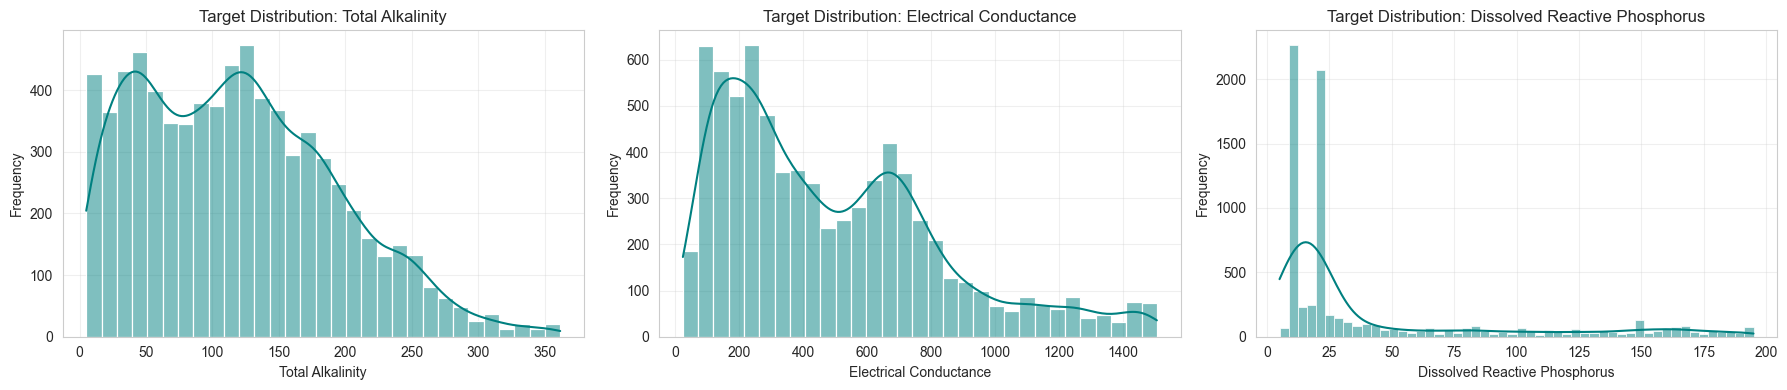

In [5]:
# Separate features by type for programmatic plotting
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

num_cols = [c for c in num_cols if c not in TARGET_COL]
cat_cols = [c for c in cat_cols if c not in TARGET_COL]

n_targets = len(TARGET_COL)
cols_per_row = 3
n_rows = (n_targets + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(18, n_rows * 4))
axes = np.array(axes).reshape(-1)  # handle 1-row/1-col safely

for idx, t_col in enumerate(TARGET_COL):
    sns.histplot(df[t_col].dropna(), kde=True, ax=axes[idx], color='teal')
    axes[idx].set_title(f"Target Distribution: {t_col}")
    axes[idx].set_xlabel(t_col)
    axes[idx].set_ylabel("Frequency")
    axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(n_targets, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Numeric Feature Distribution

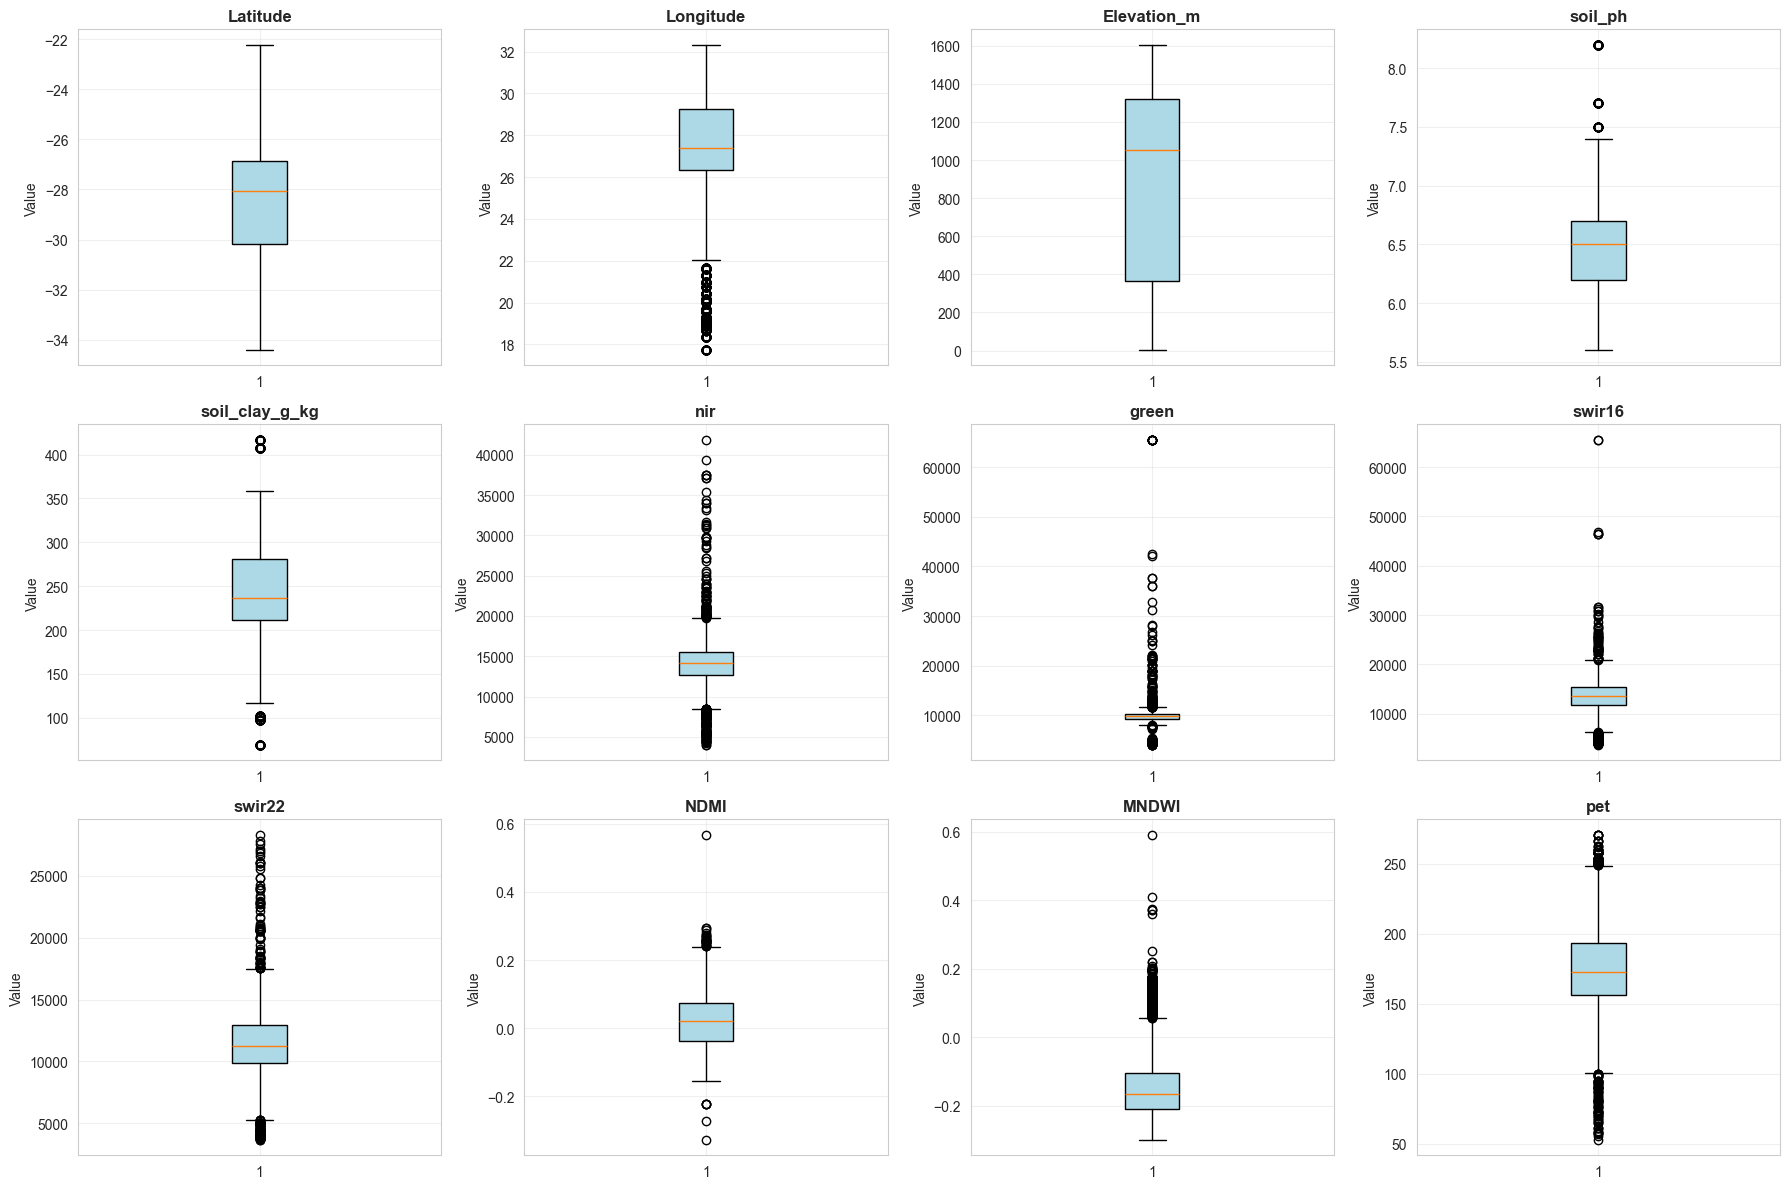

In [18]:
if num_cols:
    cols_per_row = 4
    n_rows = (len(num_cols) + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(18, n_rows * 4))
    axes = axes.flatten() # Safe because cols_per_row > 1
    
    for idx, col in enumerate(num_cols):
        axes[idx].boxplot(df[col].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
        axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(num_cols), len(axes)):
        axes[idx].set_visible(False)
        
    plt.tight_layout()
    plt.show()

,Feature,Skewness,Kurtosis
6,green,14.283,262.547
7,swir16,1.810,23.531
10,MNDWI,1.339,2.095
3,soil_ph,1.062,2.563
5,nir,1.026,9.756
1,Longitude,-0.940,0.148
8,swir22,0.802,3.918
2,Elevation_m,-0.554,-1.189
0,Latitude,-0.453,-0.284
9,NDMI,0.236,0.074


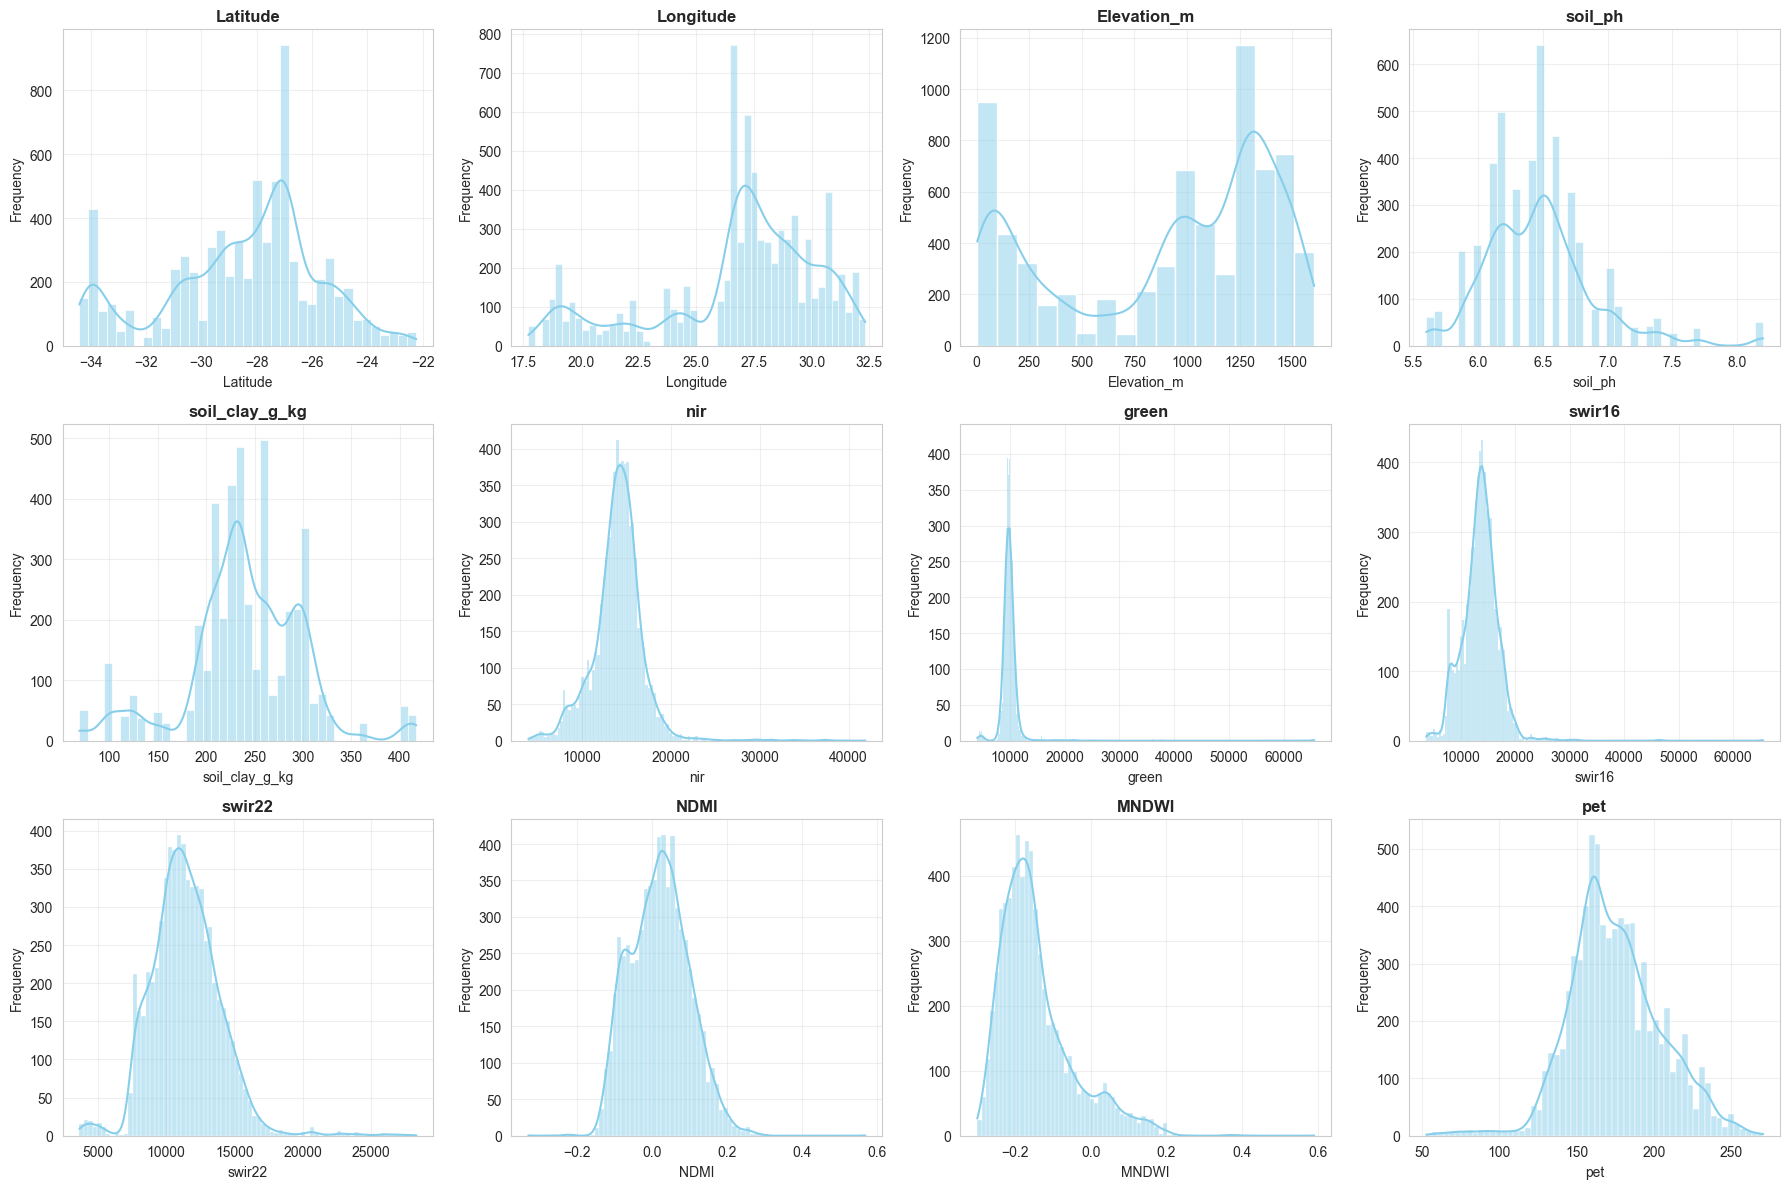

In [19]:
# Skewness and Kurtosis for numeric features
if num_cols:
    dist_stats = []
    for col in num_cols:
        dist_stats.append({
            'Feature': col,
            'Skewness': round(skew(df[col].dropna()), 3),
            'Kurtosis': round(kurtosis(df[col].dropna()), 3)
        })
    
    dist_df = pd.DataFrame(dist_stats)
    display(dist_df.sort_values(by='Skewness', key=abs, ascending=False))
    
    # Histogram + KDE plots for numeric features
    cols_per_row = 4
    n_rows = (len(num_cols) + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(18, n_rows * 4))
    axes = axes.flatten()
    
    for idx, col in enumerate(num_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[idx], color='skyblue')
        axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(num_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns for distribution analysis.")

### Categorical Feature Distribution

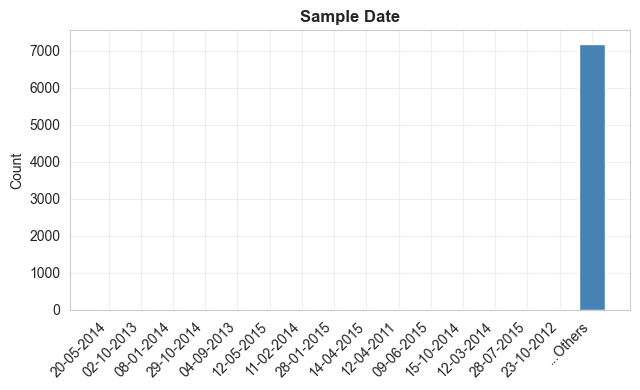

In [20]:
if cat_cols:
    cols_per_row = 3
    n_rows = (len(cat_cols) + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(18, n_rows * 4))
    axes = axes.flatten()
    
    MAX_CATEGORIES = 15 # Safety valve for high-cardinality columns
    
    for idx, col in enumerate(cat_cols):
        value_counts = df[col].value_counts()
        
        # Apply safety valve
        if len(value_counts) > MAX_CATEGORIES:
            top_counts = value_counts.iloc[:MAX_CATEGORIES]
            other_count = pd.Series({'...Others': value_counts.iloc[MAX_CATEGORIES:].sum()})
            value_counts = pd.concat([top_counts, other_count])
            
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Count')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(cat_cols), len(axes)):
        axes[idx].set_visible(False)
        
    plt.tight_layout()
    plt.show()

### Correlation Matrix

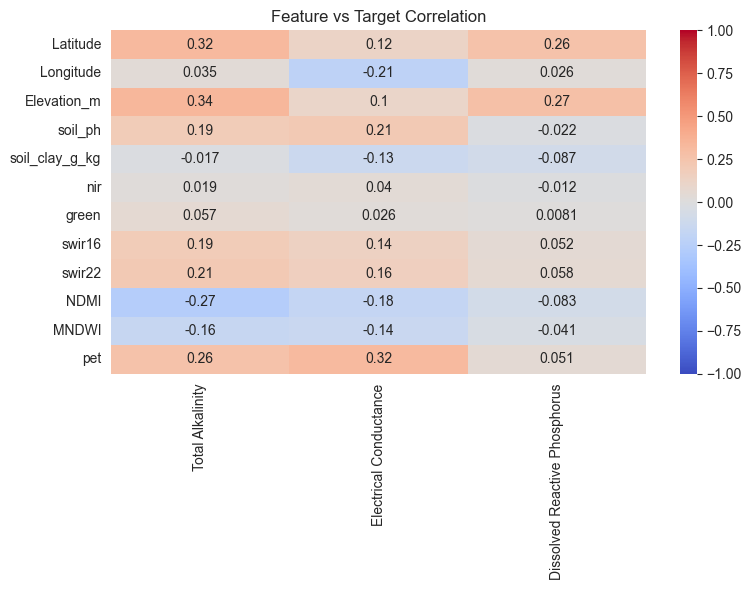

In [21]:
# Feature-to-target correlation only
feature_target_corr = df[num_cols + TARGET_COL].corr().loc[num_cols, TARGET_COL]

plt.figure(figsize=(8, max(6, len(num_cols) * 0.25)))
sns.heatmap(feature_target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Feature vs Target Correlation")
plt.tight_layout()
plt.show()

### Missing Data Patterns

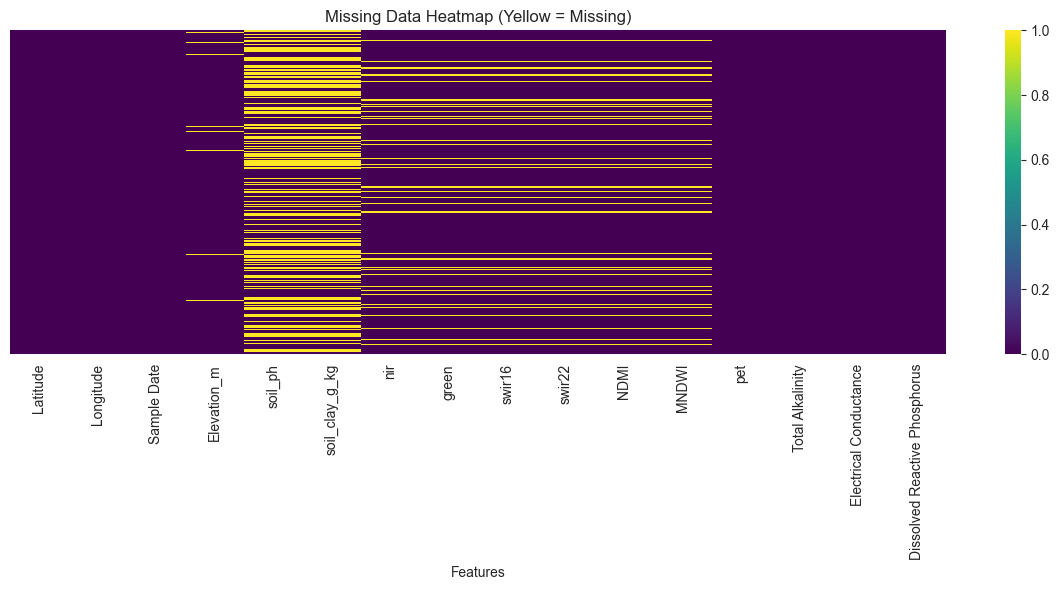

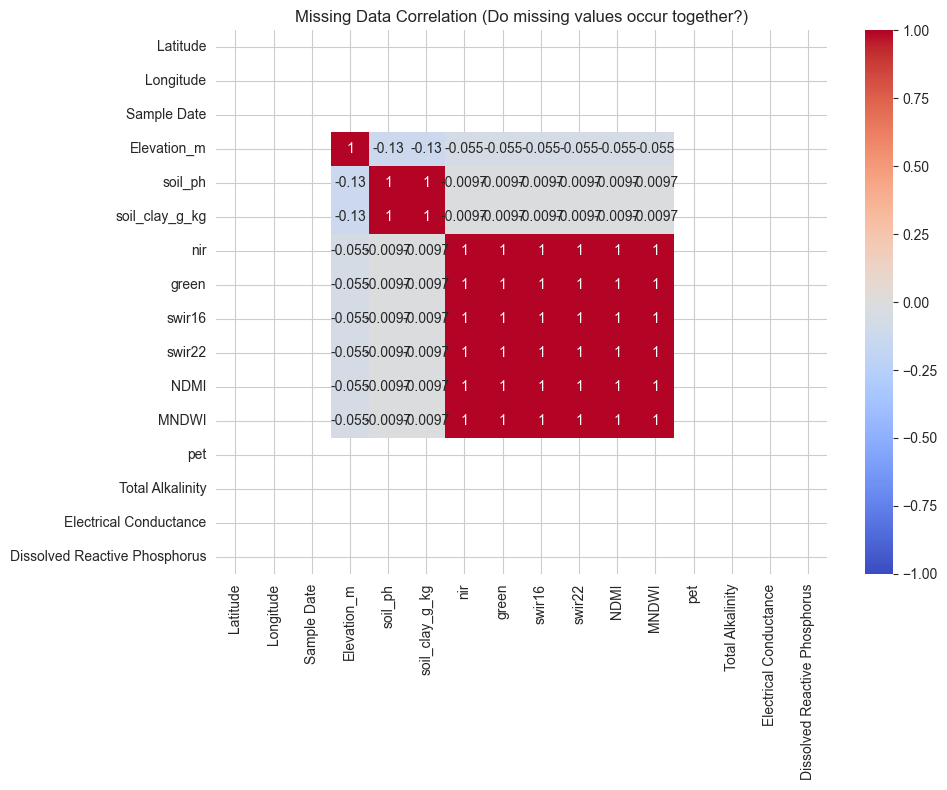

In [22]:
# Missing value heatmap
missing_data = df.isnull()

if missing_data.any().any():
    plt.figure(figsize=(12, 6))
    sns.heatmap(missing_data, cbar=True, cmap='viridis', yticklabels=False)
    plt.title("Missing Data Heatmap (Yellow = Missing)")
    plt.xlabel("Features")
    plt.tight_layout()
    plt.show()
    
    # Missing data correlation
    if missing_data.sum().sum() > 0:
        missing_corr = missing_data.corr()
        
        # Only show if there's meaningful correlation between missing values
        if (missing_corr.abs() > 0.5).sum().sum() > len(missing_corr):
            plt.figure(figsize=(10, 8))
            sns.heatmap(missing_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
            plt.title("Missing Data Correlation (Do missing values occur together?)")
            plt.tight_layout()
            plt.show()
else:
    print("✓ No missing data detected in the training set.")

### Target Relationship Analysis

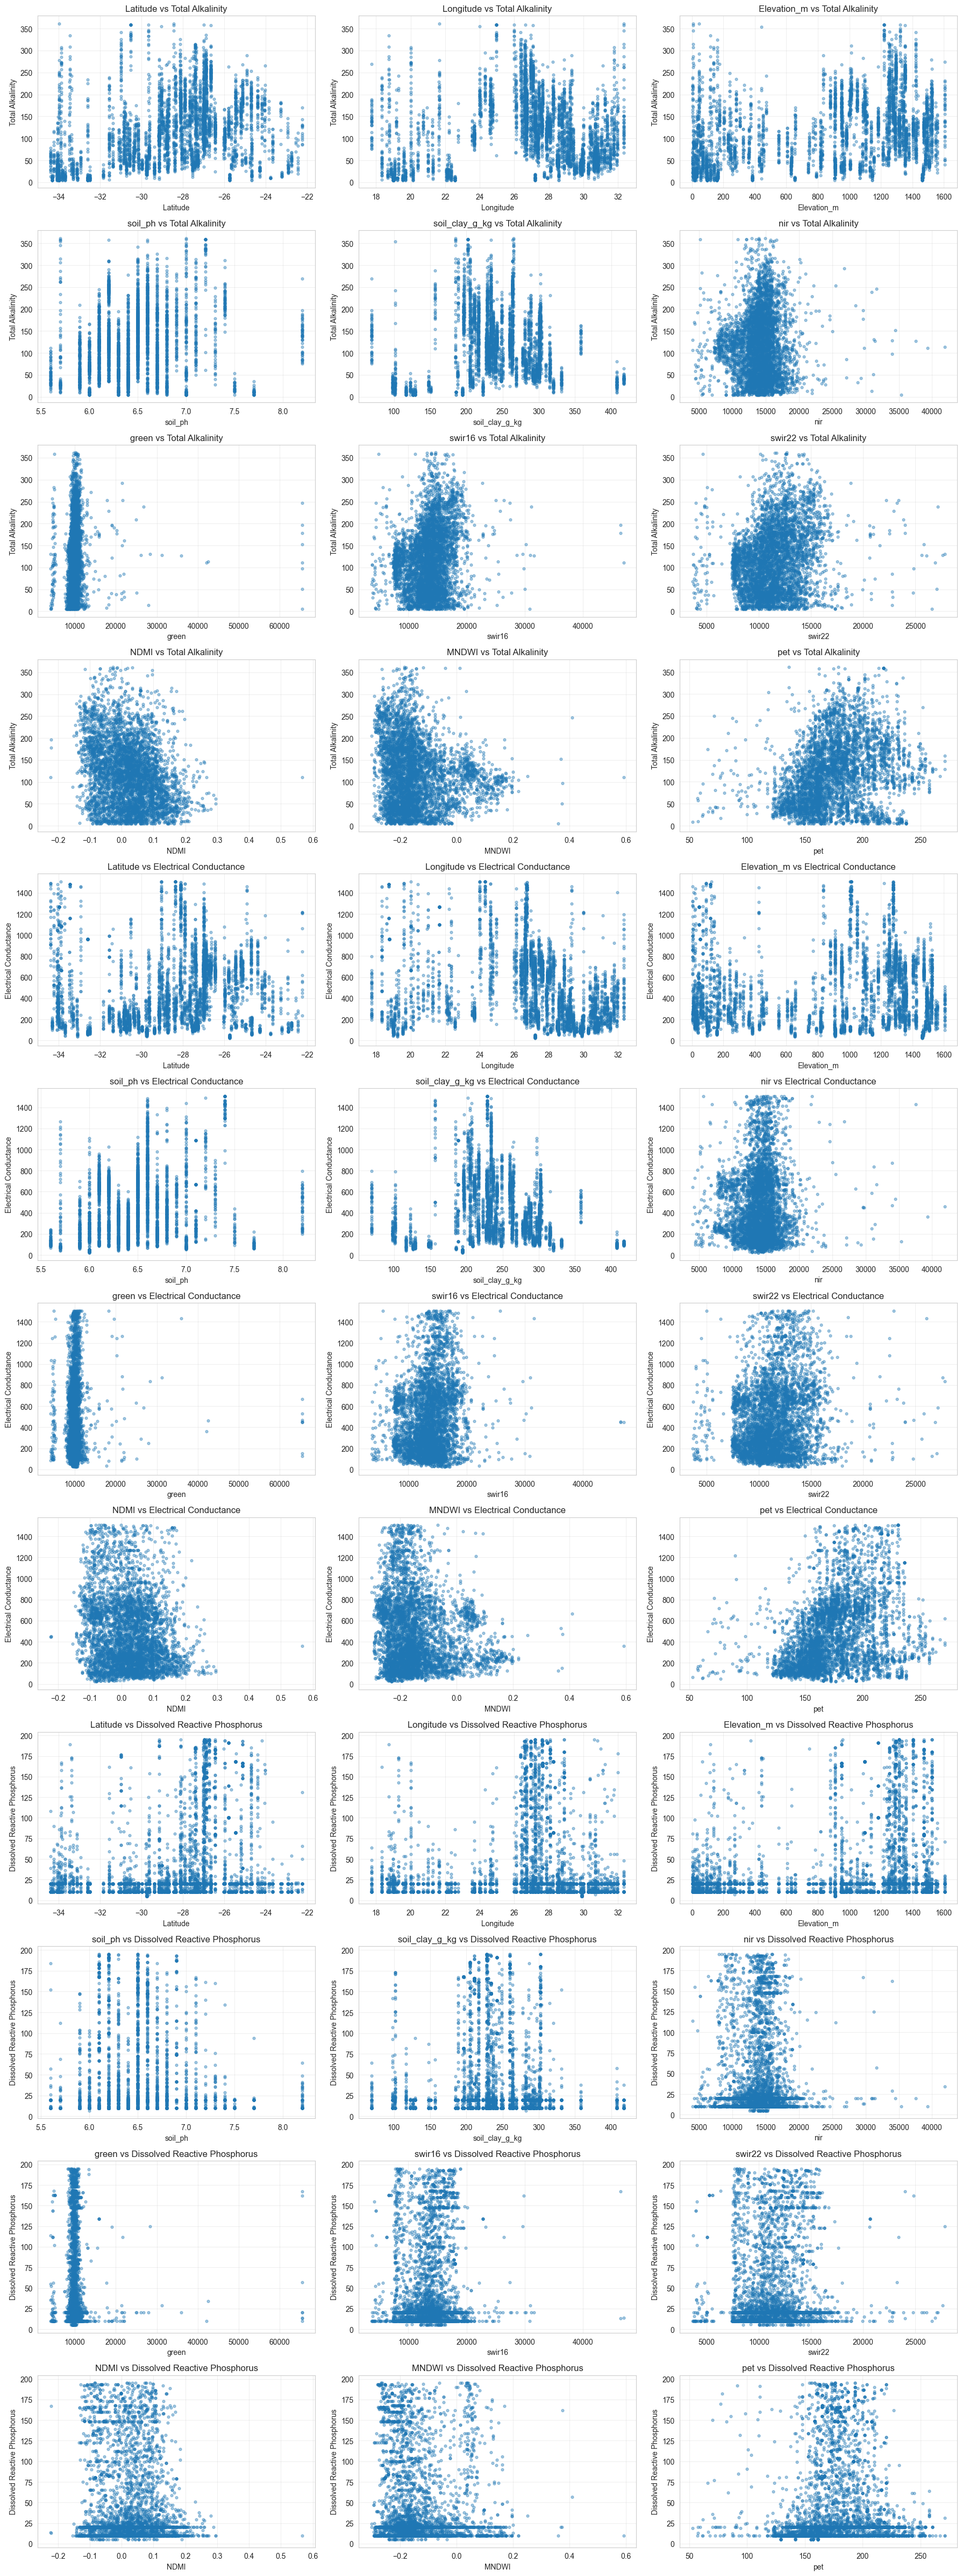

In [6]:
# Numeric Features vs Target
if num_cols and TARGET_COL:
    # For regression: scatter plots
    cols_per_row = 3
    n_plots = len(num_cols) * len(TARGET_COL)
    n_rows = (n_plots + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(18, n_rows * 4))
    axes = np.array(axes).reshape(-1)

    plot_idx = 0
    for t_col in TARGET_COL:
        for col in num_cols:
            ax = axes[plot_idx]

            # optional sampling to keep plots readable on large data
            plot_df = df[[col, t_col]].dropna()
            if len(plot_df) > 5000:
                plot_df = plot_df.sample(5000, random_state=42)

            ax.scatter(plot_df[col], plot_df[t_col], alpha=0.4, s=12)
            ax.set_xlabel(col)
            ax.set_ylabel(t_col)
            ax.set_title(f"{col} vs {t_col}")
            ax.grid(True, alpha=0.3)

            plot_idx += 1

    # Hide empty subplots
    for idx in range(plot_idx, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numeric features or target columns available for regression relationship plots.")

### Outlier Detection (IQR Method)

,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
1,Longitude,996,13.36,22.01,33.58
5,nir,358,4.80,8484.25,19734.25
10,MNDWI,346,4.64,-0.37,0.06
6,green,332,4.45,8004.38,11659.38
4,soil_clay_g_kg,279,3.74,106.00,386.00
8,swir22,166,2.23,5254.38,17507.38
11,pet,162,2.17,100.85,248.45
7,swir16,138,1.85,6282.50,20920.50
3,soil_ph,116,1.56,5.45,7.45
9,NDMI,34,0.46,-0.20,0.24


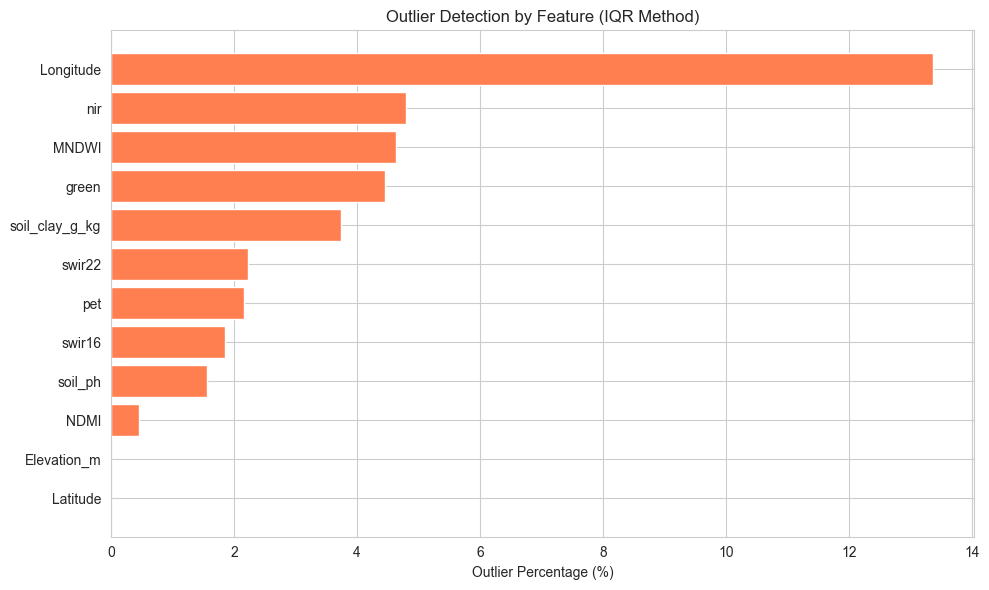

In [7]:
# Identify outliers using IQR method
if num_cols:
    outlier_summary = []
    
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(df)) * 100
        
        outlier_summary.append({
            'Feature': col,
            'Outlier Count': outlier_count,
            'Outlier %': round(outlier_pct, 2),
            'Lower Bound': round(lower_bound, 2),
            'Upper Bound': round(upper_bound, 2)
        })
    
    outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outlier %', ascending=False)
    display(outlier_df)
    
    # Visualize outlier percentage
    if outlier_df['Outlier %'].sum() > 0:
        plt.figure(figsize=(10, 6))
        plt.barh(outlier_df['Feature'], outlier_df['Outlier %'], color='coral')
        plt.xlabel('Outlier Percentage (%)')
        plt.title('Outlier Detection by Feature (IQR Method)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print("No numeric columns to check for outliers.")

### Temporal Analysis (If Applicable)

Using date column: Sample Date
Date range: 2011-01-03 to 2015-12-31


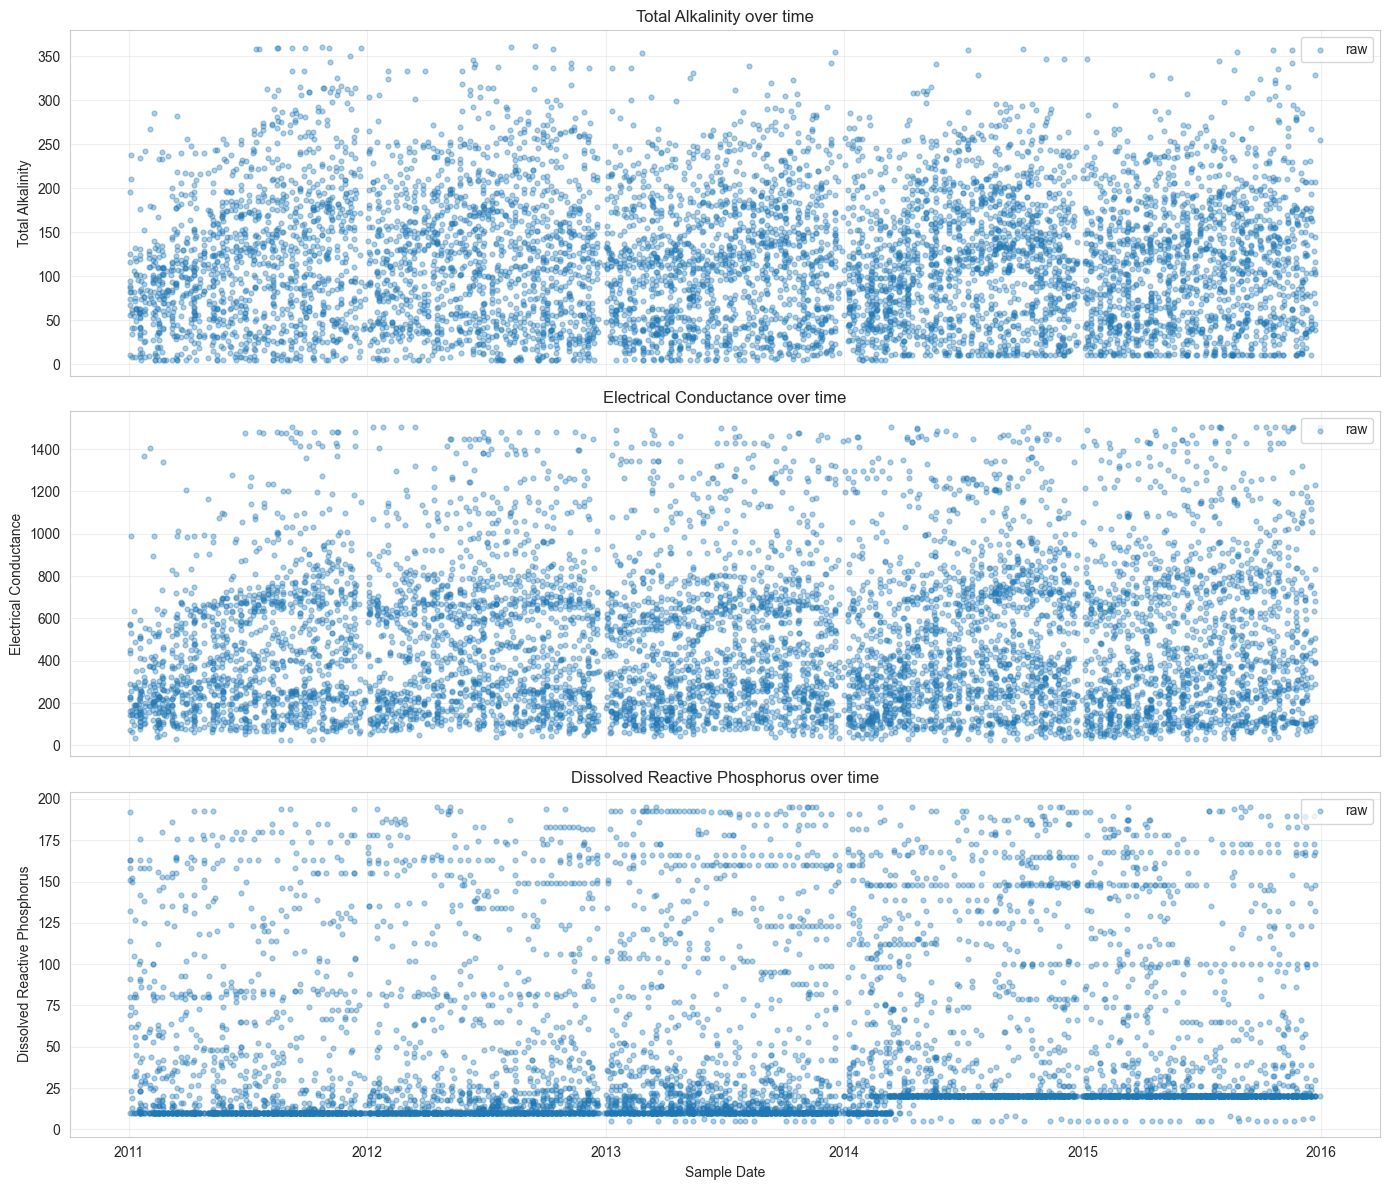

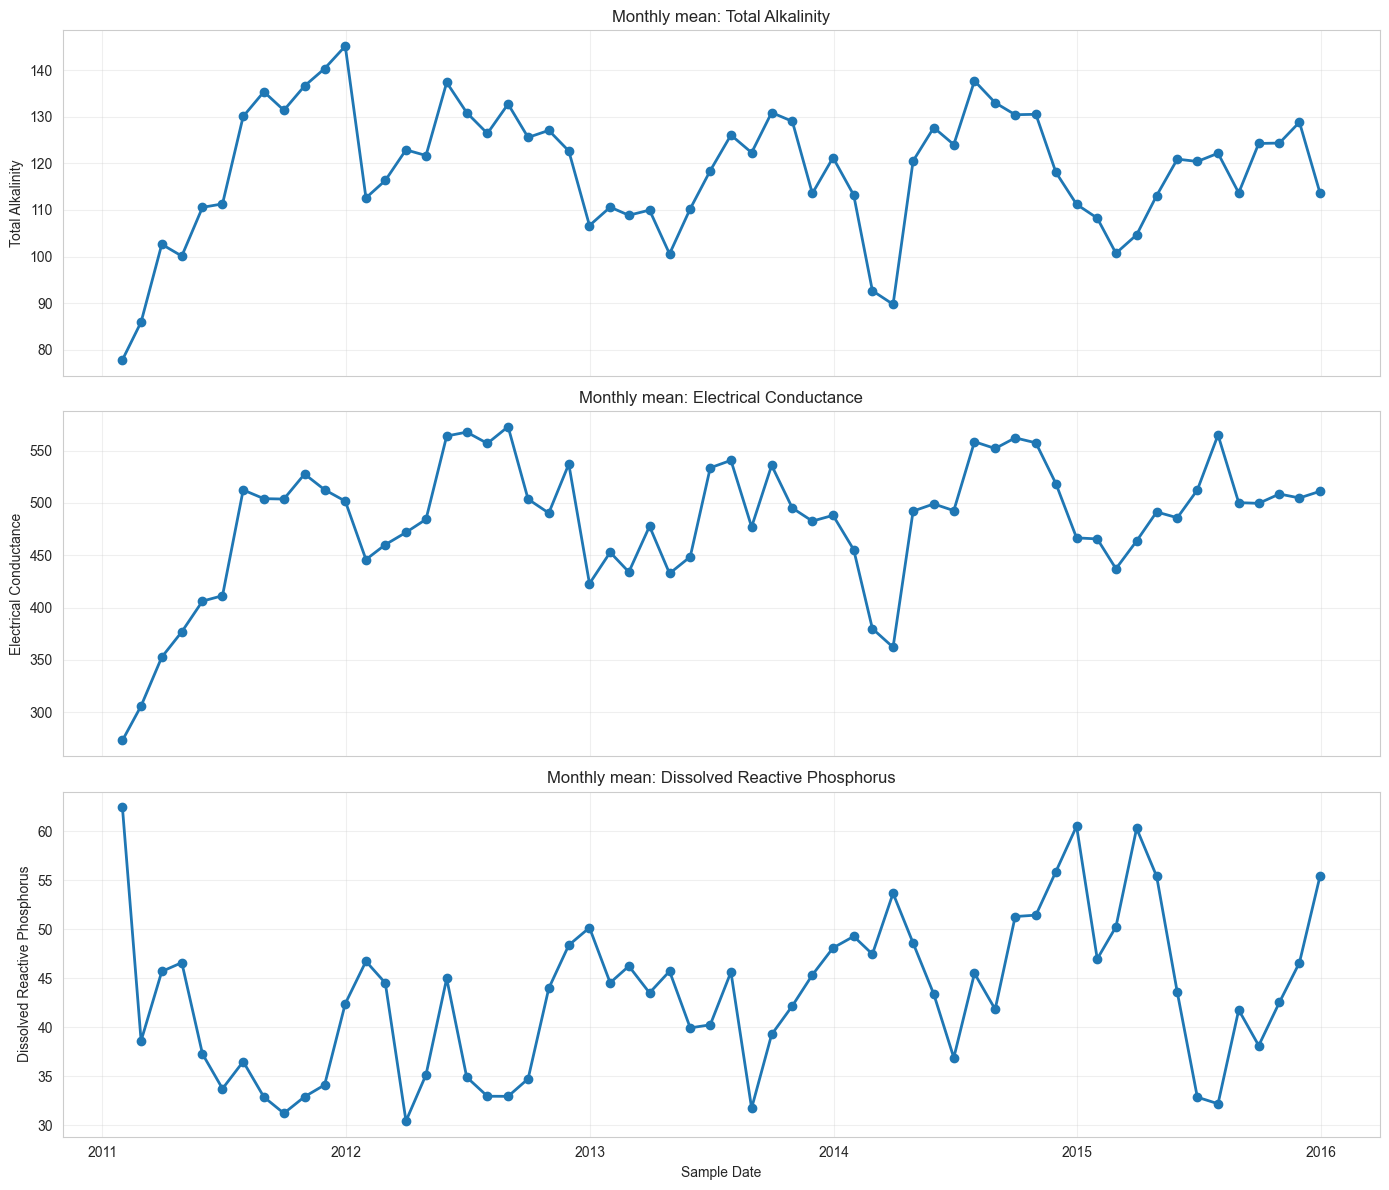

In [11]:
# Temporal analysis for multi-target regression
DATE_COL = "Sample Date"

if DATE_COL in df.columns:
    # Safe datetime parse
    df_time = df.copy()
    df_time[DATE_COL] = pd.to_datetime(df_time[DATE_COL], errors="coerce", dayfirst=True)

    # Drop rows where date failed to parse
    df_time = df_time.dropna(subset=[DATE_COL]).sort_values(DATE_COL)

    if len(df_time) == 0:
        print(f"No valid datetime values found in '{DATE_COL}'.")
    else:
        print(f"Using date column: {DATE_COL}")
        print(f"Date range: {df_time[DATE_COL].min().date()} to {df_time[DATE_COL].max().date()}")

        # 1) Raw scatter per target over time
        n_targets = len(TARGET_COL)
        fig, axes = plt.subplots(n_targets, 1, figsize=(14, 4 * n_targets), sharex=True)
        axes = np.array(axes).reshape(-1)

        for i, t_col in enumerate(TARGET_COL):
            plot_df = df_time[[DATE_COL, t_col]].dropna()
            axes[i].scatter(plot_df[DATE_COL], plot_df[t_col], alpha=0.35, s=12, label="raw")
            axes[i].set_title(f"{t_col} over time")
            axes[i].set_ylabel(t_col)
            axes[i].grid(True, alpha=0.3)
            axes[i].legend(loc="upper right")

        axes[-1].set_xlabel(DATE_COL)
        plt.tight_layout()
        plt.show()

        # 2) Monthly trend per target (mean)
        monthly = (
            df_time.set_index(DATE_COL)[TARGET_COL]
            .resample("ME")
            .mean()
            .dropna(how="all")
        )

        if not monthly.empty:
            fig, axes = plt.subplots(n_targets, 1, figsize=(14, 4 * n_targets), sharex=True)
            axes = np.array(axes).reshape(-1)

            for i, t_col in enumerate(TARGET_COL):
                axes[i].plot(monthly.index, monthly[t_col], marker="o", linewidth=2)
                axes[i].set_title(f"Monthly mean: {t_col}")
                axes[i].set_ylabel(t_col)
                axes[i].grid(True, alpha=0.3)

            axes[-1].set_xlabel(DATE_COL)
            plt.tight_layout()
            plt.show()
        else:
            print("Not enough data to compute monthly trends.")
else:
    print("No temporal features detected. Set DATE_COL to your date column name.")

### Cardinality Check

In [ ]:
# # Identify high-cardinality categorical features
# if cat_cols:
#     cardinality_info = []
    
#     for col in cat_cols:
#         unique_count = df[col].nunique()
#         cardinality_pct = (unique_count / len(df)) * 100
        
#         cardinality_info.append({
#             'Feature': col,
#             'Unique Values': unique_count,
#             'Cardinality %': round(cardinality_pct, 2),
#             'Type': 'High' if unique_count > 50 else ('Medium' if unique_count > 10 else 'Low')
#         })
    
#     cardinality_df = pd.DataFrame(cardinality_info).sort_values(by='Unique Values', ascending=False)
#     display(cardinality_df)
    
#     # Flag high-cardinality features that may need special encoding
#     high_card_features = cardinality_df[cardinality_df['Type'] == 'High']['Feature'].tolist()
#     if high_card_features:
#         print(f"\n⚠️ High-cardinality features detected: {high_card_features}")
#         print("   Consider: Target encoding, frequency encoding, or feature hashing.")
# else:
#     print("No categorical columns to check for cardinality.")

### Class Imbalance Analysis

In [ ]:
# # Check for class imbalance (for classification tasks)
# if df[TARGET_COL].dtype == 'object' or df[TARGET_COL].nunique() < 20:
#     value_counts = df[TARGET_COL].value_counts()
#     value_pcts = df[TARGET_COL].value_counts(normalize=True) * 100
    
#     imbalance_df = pd.DataFrame({
#         'Class': value_counts.index,
#         'Count': value_counts.values,
#         'Percentage': [f"{pct:.2f}%" for pct in value_pcts.values]
#     })
    
#     print("Class Distribution:")
#     display(imbalance_df)
    
#     # Calculate imbalance ratio
#     if len(value_counts) == 2:
#         imbalance_ratio = value_counts.max() / value_counts.min()
#         print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
        
#         if imbalance_ratio > 3:
#             print("⚠️ Significant class imbalance detected!")
#             print("   Consider: SMOTE, class weights, or stratified sampling.")
    
#     # Visualization
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
#     # Count plot
#     axes[0].bar(range(len(value_counts)), value_counts.values, color='steelblue')
#     axes[0].set_xticks(range(len(value_counts)))
#     axes[0].set_xticklabels(value_counts.index, rotation=45)
#     axes[0].set_title('Class Distribution (Count)')
#     axes[0].set_ylabel('Count')
#     axes[0].grid(True, alpha=0.3)
    
#     # Pie chart
#     axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
#     axes[1].set_title('Class Distribution (Percentage)')
    
#     plt.tight_layout()
#     plt.show()
# else:
#     print("Target variable is continuous (regression task). Class imbalance analysis not applicable.")

### Multicollinearity Check

In [12]:
# VIF (Variance Inflation Factor) Analysis
if len(num_cols) > 1:
    # Prepare data for VIF (drop NaNs)
    vif_data = df[num_cols].dropna()
    
    if len(vif_data) > 0 and vif_data.shape[1] > 1:
        vif_values = []
        
        for i, col in enumerate(vif_data.columns):
            try:
                vif = variance_inflation_factor(vif_data.values, i)
                vif_values.append({
                    'Feature': col,
                    'VIF': round(vif, 2)
                })
            except:
                vif_values.append({
                    'Feature': col,
                    'VIF': 'Error'
                })
        
        vif_df = pd.DataFrame(vif_values).sort_values(by='VIF', ascending=False, key=lambda x: pd.to_numeric(x, errors='coerce'))
        display(vif_df)
        
        print("\n💡 VIF Interpretation:")
        print("   VIF < 5: Low multicollinearity")
        print("   VIF 5-10: Moderate multicollinearity")
        print("   VIF > 10: High multicollinearity (consider removing)")
    
    # High correlation pairs
    print("\n" + "="*50)
    print("High Correlation Pairs (|r| > 0.8):")
    print("="*50)
    
    corr_matrix = df[num_cols].corr()
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.8:
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': round(corr_val, 3)
                })
    
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlation', key=abs, ascending=False)
        display(high_corr_df)
        print("\n⚠️ Consider removing one feature from each highly correlated pair.")
    else:
        print("✓ No highly correlated feature pairs detected (|r| > 0.8).")
else:
    print("Not enough numeric columns for multicollinearity analysis.")

,Feature,VIF
5,nir,1161.47
7,swir16,745.95
8,swir22,520.63
3,soil_ph,283.32
6,green,169.80
0,Latitude,121.96
1,Longitude,121.74
11,pet,92.81
10,MNDWI,70.00
4,soil_clay_g_kg,46.29



💡 VIF Interpretation:
   VIF < 5: Low multicollinearity
   VIF 5-10: Moderate multicollinearity
   VIF > 10: High multicollinearity (consider removing)

High Correlation Pairs (|r| > 0.8):


,Feature 1,Feature 2,Correlation
0,swir16,swir22,0.951



⚠️ Consider removing one feature from each highly correlated pair.
